In [1]:
"""
Segmentación por watershed
Este notebook presenta la segmentación por watershed para separar objetos que se tocan o se superponen en imágenes binarias.
El etiquetado de componentes conectados funciona bien cuando los objetos están claramente separados, pero falla cuando las regiones vecinas se fusionan en un único componente conectado. 
La segmentación por watershed ayuda a resolver este problema dividiendo las regiones fusionadas mediante conceptos topográficos y segmentación basada en marcadores.
Objetivos de aprendizaje
- Comprender por qué fallan los componentes conectados para objetos que se tocan.
- Interpretar conceptualmente la segmentación por watershed.
- Utilizar la transformada de distancia para identificar los centros de los objetos.
- Crear marcadores para la segmentación por watershed.
- Separar los objetos fusionados en regiones individuales.
- Comparar la segmentación antes y después de la segmentación por watershed.
Contexto de la imagen reales
La segmentación por watershed se utiliza ampliamente en la imagen para:
- Separar partículas que se tocan.
- Separar poros o granos fusionados.
- Segmentación de células y núcleos.
- Conteo de objetos en imágenes con alta densidad de objetos.
- Mejorar el análisis cuantitativo basado en regiones.
"""

'\nSegmentación por watershed\nEste notebook presenta la segmentación por watershed para separar objetos que se tocan o se superponen en imágenes binarias.\nEl etiquetado de componentes conectados funciona bien cuando los objetos están claramente separados, pero falla cuando las regiones vecinas se fusionan en un único componente conectado. \nLa segmentación por watershed ayuda a resolver este problema dividiendo las regiones fusionadas mediante conceptos topográficos y segmentación basada en marcadores.\nObjetivos de aprendizaje\n- Comprender por qué fallan los componentes conectados para objetos que se tocan.\n- Interpretar conceptualmente la segmentación por watershed.\n- Utilizar la transformada de distancia para identificar los centros de los objetos.\n- Crear marcadores para la segmentación por watershed.\n- Separar los objetos fusionados en regiones individuales.\n- Comparar la segmentación antes y después de la segmentación por watershed.\nContexto de la imagen reales\nLa segme

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import ndimage as ndi

from skimage import data, filters, measure, morphology, segmentation, feature, color, util
from skimage.draw import disk

In [3]:
def show_image(image, title="", cmap="gray", save_path=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def compare_images(images, titles, cmap="gray", figsize=(15, 5), save_path=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)

    if len(images) == 1:
        axes = [axes]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def save_dataframe_csv(df, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(save_path, index=False)

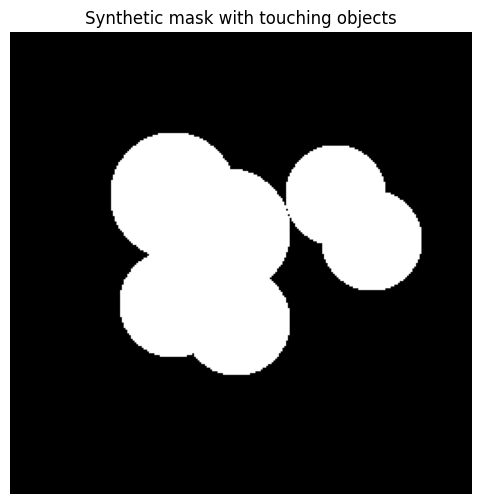

In [14]:
mask = np.zeros((256, 256), dtype=bool)

disks = [
    ((90, 90), 35),
    ((110, 120), 35),
    ((150, 90), 30),
    ((160, 125), 30),
    ((90, 180), 28),
    ((115, 200), 28),
]

for center, radius in disks:
    rr, cc = disk(center, radius, shape=mask.shape)
    mask[rr, cc] = True

show_image(
    mask,
    "Synthetic mask with touching objects",
    save_path="../figures/figures_watershed_segmentation/synthetic_touching_objects.png"
)

Numero de Componentes conectados antes de la división por watershed: 1


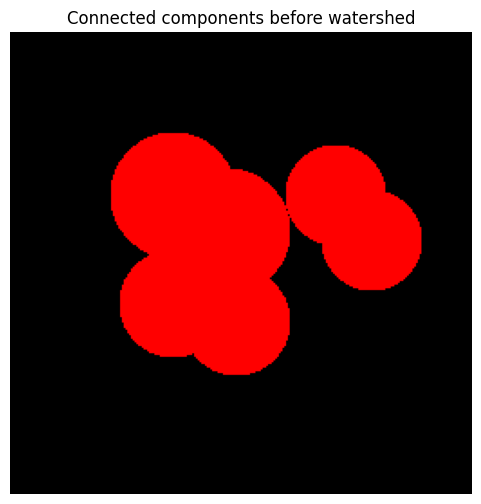

In [15]:
"""
Componentes conectados antes de la división por watershed
Si etiquetamos directamente la máscara binaria, los objetos que se tocan se agrupan en regiones conectadas fusionadas.
"""
labels_before = measure.label(mask, connectivity=2)

print(f"Numero de Componentes conectados antes de la división por watershed: {labels_before.max()}")

show_image(
    color.label2rgb(labels_before, bg_label=0),
    "Connected components before watershed",
    cmap=None,
    save_path="../figures/figures_watershed_segmentation/connected_components_before_watershed.png"
)


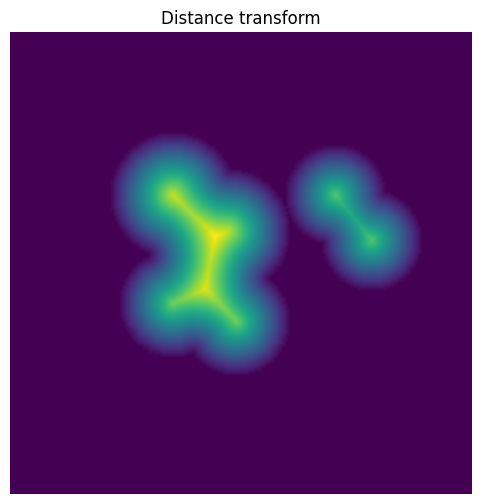

In [16]:
"""
Transformada de la distancia
Una estrategia común de segmentación por watershed para máscaras binarias consiste en calcular la transformada de la distancia.
Para cada píxel de primer plano, la transformada de la distancia mide la distancia al píxel de fondo más cercano.
Los centros de los objetos suelen tener valores de distancia mayores, por lo que el mapa de distancia ayuda a identificar posibles interiores de objetos.
"""
distance_map = ndi.distance_transform_edt(mask)

show_image(
    distance_map,
    "Distance transform",
    cmap="viridis",
    save_path="../figures/figures_watershed_segmentation/distance_transform.png"
)

Numero de marcadores: 5


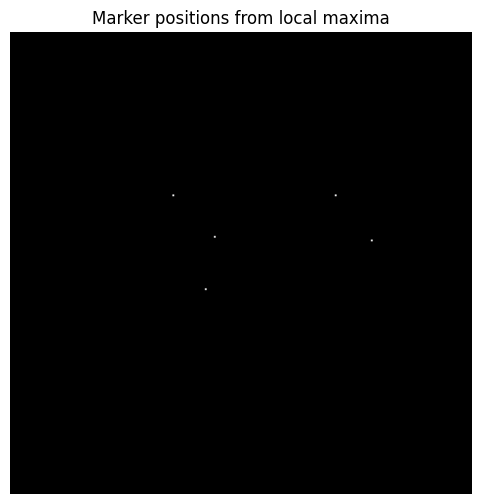

In [22]:
"""
Detección de máximos locales como marcadores
Para aplicar el algoritmo de segmentación por cuencas hidrográficas, necesitamos marcadores que representen los centros probables de los objetos.
Un enfoque común consiste en detectar los máximos locales en el mapa de distancias.
"""
coords = feature.peak_local_max(
    distance_map,
    labels=mask,
    footprint=np.ones((25, 25))
)

marker_mask = np.zeros(distance_map.shape, dtype=bool)
marker_mask[tuple(coords.T)] = True

markers, _ = ndi.label(marker_mask)

print(f"Numero de marcadores: {markers.max()}")

show_image(
    marker_mask,
    "Marker positions from local maxima",
    save_path="../figures/figures_watershed_segmentation/marker_positions.png"
)

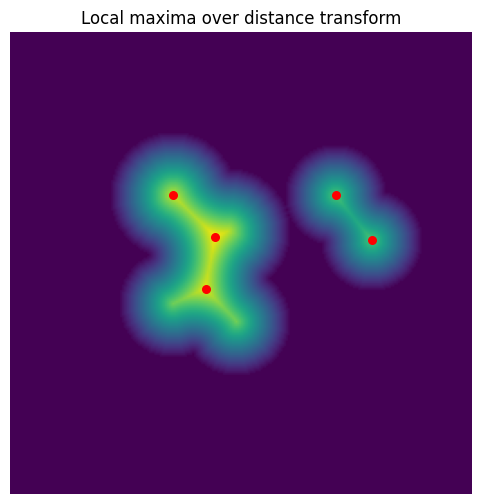

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(distance_map, cmap="viridis")
ax.scatter(coords[:, 1], coords[:, 0], s=30, c="red")
ax.set_title("Local maxima over distance transform")
ax.axis("off")

plt.savefig(
    "../figures/figures_watershed_segmentation/local_maxima_over_distance_map.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

Number of objects after watershed: 5


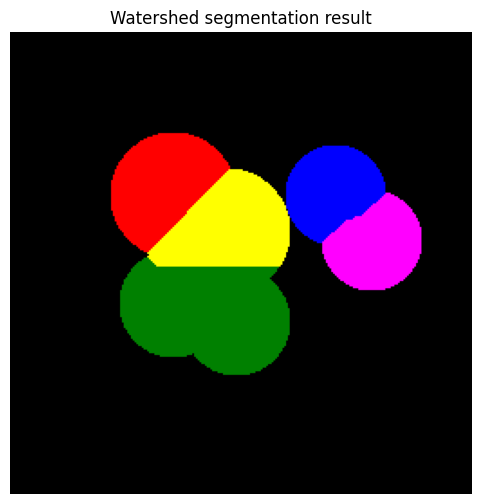

In [24]:
"""
Segmentación por watershed
Ahora, el algoritmo de watershed puede generar regiones a partir de los marcadores.
Al usar el mapa de distancia negativa, los centros de los objetos actúan como cuencas, por lo que la segmentación se expande hacia afuera hasta que las regiones vecinas se encuentran.
"""
labels_ws = segmentation.watershed(-distance_map, markers, mask=mask)

print(f"Number of objects after watershed: {labels_ws.max()}")

show_image(
    color.label2rgb(labels_ws, bg_label=0),
    "Watershed segmentation result",
    cmap=None,
    save_path="../figures/figures_watershed_segmentation/watershed_result.png"
)

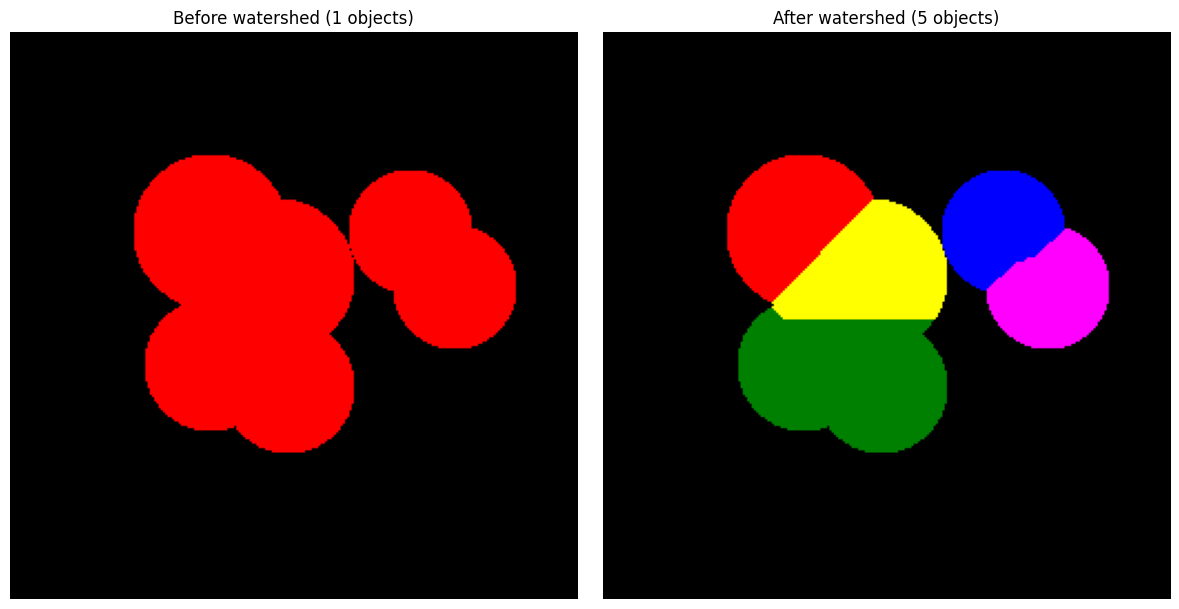

In [25]:
"""
Comparación antes y después de la segmentación
Esta comparación muestra cómo la segmentación separa las regiones conectadas fusionadas en objetos individuales etiquetados.
"""
compare_images(
    [
        color.label2rgb(labels_before, bg_label=0),
        color.label2rgb(labels_ws, bg_label=0)
    ],
    [
        f"Before watershed ({labels_before.max()} objects)",
        f"After watershed ({labels_ws.max()} objects)"
    ],
    cmap=None,
    figsize=(12, 6),
    save_path="../figures/figures_watershed_segmentation/before_after_watershed.png"
)

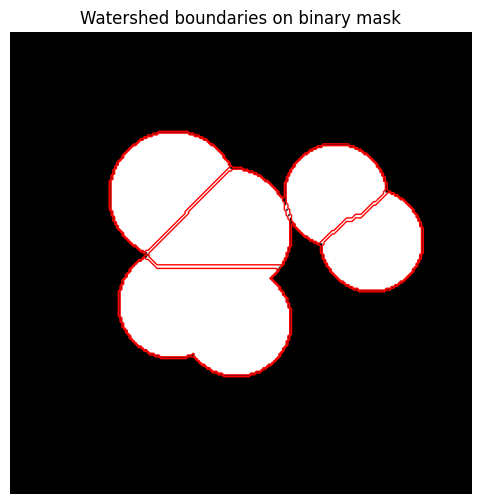

In [26]:
"""
Límites de watershed
A menudo resulta útil visualizar explícitamente los límites de segmentación.
"""
boundaries = segmentation.find_boundaries(labels_ws, mode="outer")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(mask, cmap="gray")
ax.contour(boundaries, colors="red", linewidths=1)
ax.set_title("Watershed boundaries on binary mask")
ax.axis("off")

plt.savefig(
    "../figures/figures_watershed_segmentation/watershed_boundaries.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

In [27]:
"""
Propiedades de la región tras el análisis de watershed
Tras separar los objetos, podemos medirlos individualmente utilizando las mismas herramientas de componentes conectados y propiedades de región que presentamos anteriormente.
"""
props_ws = measure.regionprops_table(
    labels_ws,
    properties=[
        "label",
        "area",
        "centroid",
        "equivalent_diameter",
        "eccentricity",
        "perimeter",
        "solidity"
    ]
)

df_ws = pd.DataFrame(props_ws)
df_ws

,label,area,centroid-0,centroid-1,equivalent_diameter,eccentricity,perimeter,solidity
0,1,2745.0,84.022222,83.829872,59.118885,0.731844,203.764502,0.984930
1,2,2068.0,86.866538,177.768859,51.313345,0.604534,172.409163,0.969526
2,3,2935.0,107.804089,121.112436,61.130664,0.745870,219.480231,0.990550
3,4,2068.0,118.133462,202.231141,51.313345,0.604534,172.409163,0.969526
4,5,4683.0,156.112748,108.801836,77.217749,0.801215,282.101551,0.933799


In [28]:
save_dataframe_csv(
    df_ws,
    "../figures/figures_watershed_segmentation/watershed_region_properties.csv"
)

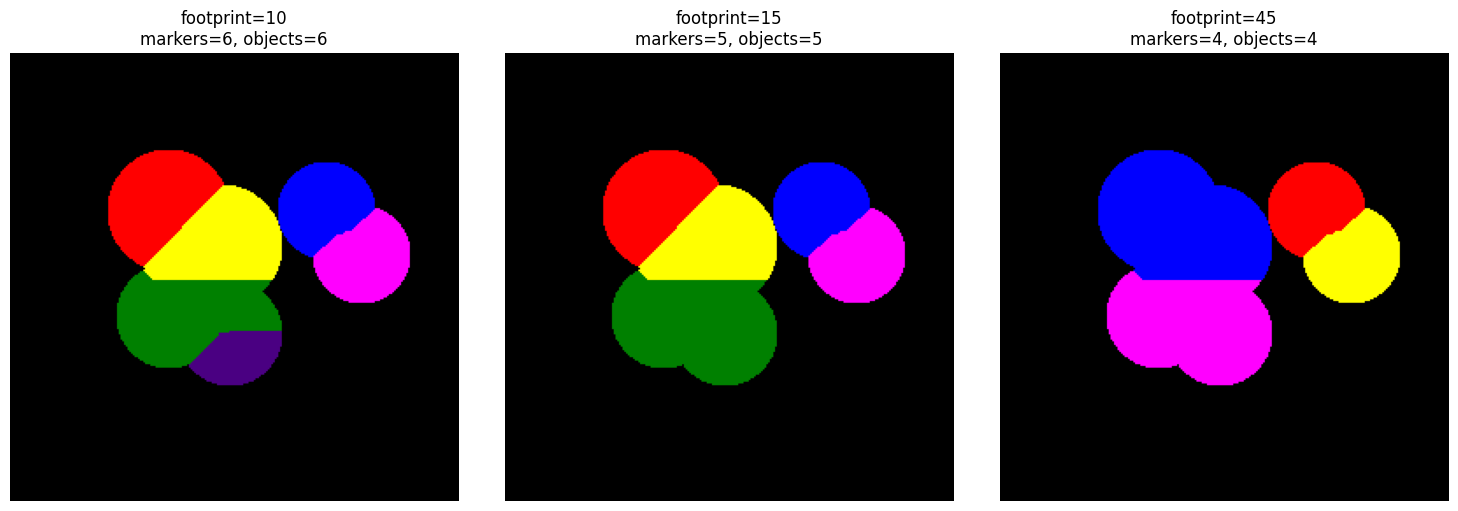

In [34]:
"""
Sensibilidad de los parámetros: detección de marcadores
Los resultados del análisis de watershed dependen en gran medida de la selección de marcadores.
Si se detectan demasiados marcadores, el resultado puede estar sobresegmentado. Si se detectan muy pocos, diferentes objetos pueden permanecer fusionados.
Aquí comparamos la detección de marcadores utilizando diferentes tamaños de huella.
"""
footprints = [10, 15, 45]
marker_counts = []
watershed_counts = []

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, fp in zip(axes, footprints):
    coords_fp = feature.peak_local_max(
        distance_map,
        labels=mask,
        footprint=np.ones((fp, fp))
    )

    marker_mask_fp = np.zeros(distance_map.shape, dtype=bool)
    marker_mask_fp[tuple(coords_fp.T)] = True
    markers_fp, _ = ndi.label(marker_mask_fp)

    labels_fp = segmentation.watershed(-distance_map, markers_fp, mask=mask)

    marker_counts.append(markers_fp.max())
    watershed_counts.append(labels_fp.max())

    ax.imshow(color.label2rgb(labels_fp, bg_label=0))
    ax.set_title(f"footprint={fp}\nmarkers={markers_fp.max()}, objects={labels_fp.max()}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    "../figures/figures_watershed_segmentation/marker_sensitivity_comparison.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

In [35]:
"""
Interpretación
La selección de marcadores es uno de los pasos más importantes en la segmentación por watershed.
Por eso, la segmentación por watershed basada en marcadores es potente, pero también sensible:
- Demasiados marcadores pueden dividir un mismo objeto en varias regiones.
- Muy pocos marcadores pueden dejar objetos contiguos fusionados.
"""

'\nInterpretación\nLa selección de marcadores es uno de los pasos más importantes en la segmentación por watershed.\nPor eso, la segmentación por watershed basada en marcadores es potente, pero también sensible:\n- Demasiados marcadores pueden dividir un mismo objeto en varias regiones.\n- Muy pocos marcadores pueden dejar objetos contiguos fusionados.\n'

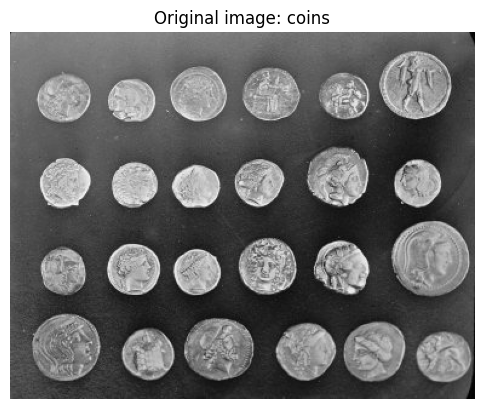

In [36]:
"""
Volvemos a retomar el ejemplo de la imagen con monedas
"""
image = data.coins()

show_image(
    image,
    "Original image: coins",
    save_path="../figures/figures_watershed_segmentation/coins_original.png"
)

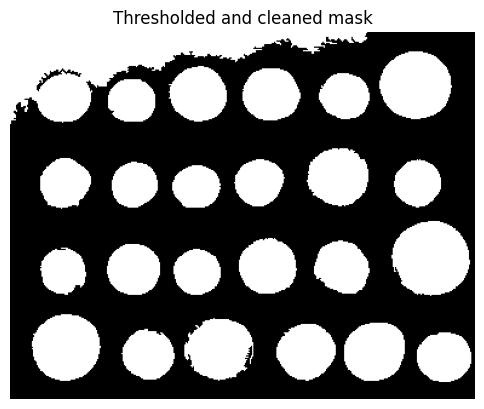

In [68]:
threshold = filters.threshold_otsu(image)
binary = image > threshold
binary = morphology.remove_small_objects(binary, max_size=150)
binary = morphology.remove_small_holes(binary, max_size=80)

show_image(
    binary,
    "Thresholded and cleaned mask",
    save_path="../figures/figures_watershed_segmentation/coins_binary_clean.png"
)

In [69]:
distance_coins = ndi.distance_transform_edt(binary)

coords_coins = feature.peak_local_max(
    distance_coins,
    labels=binary,
    footprint=np.ones((21, 21))
)

marker_mask_coins = np.zeros(distance_coins.shape, dtype=bool)
marker_mask_coins[tuple(coords_coins.T)] = True
markers_coins, _ = ndi.label(marker_mask_coins)

labels_coins_ws = segmentation.watershed(-distance_coins, markers_coins, mask=binary)

print(f"Detected objects after watershed on coins image: {labels_coins_ws.max()}")

Detected objects after watershed on coins image: 32


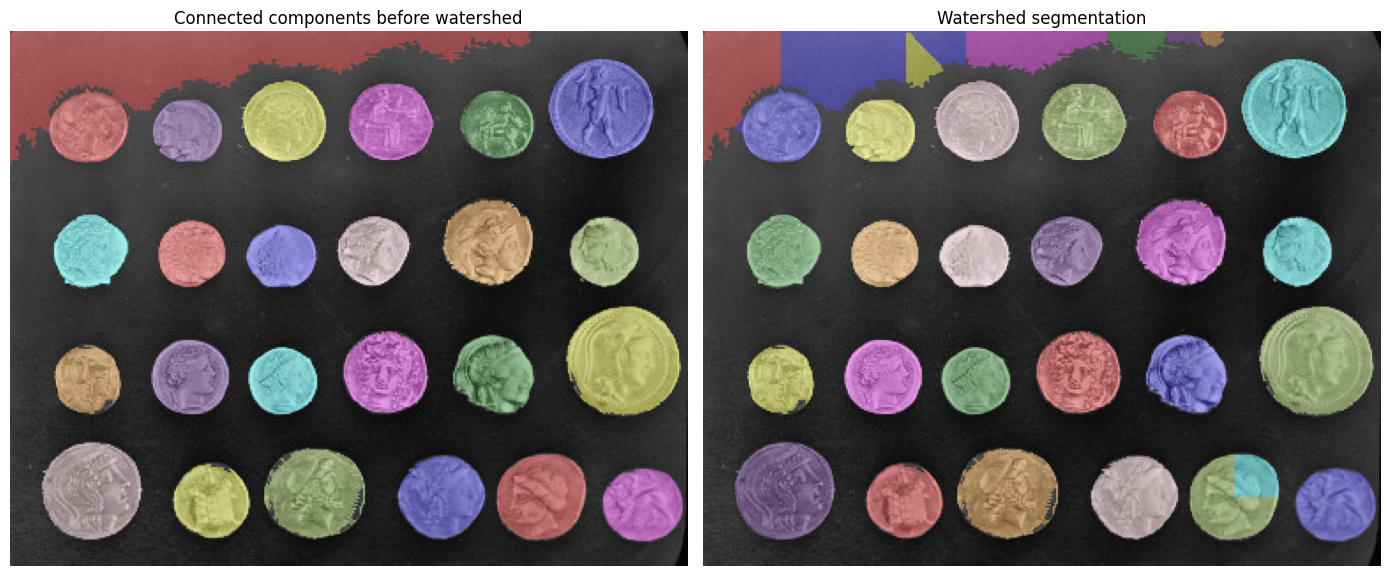

In [71]:
compare_images(
    [
        color.label2rgb(measure.label(binary), image=image, bg_label=0),
        color.label2rgb(labels_coins_ws, image=image, bg_label=0)
    ],
    [
        "Connected components before watershed",
        "Watershed segmentation"
    ],
    cmap=None,
    figsize=(14, 6),
    save_path="../figures/figures_watershed_segmentation/coins_before_after_watershed.png"
)

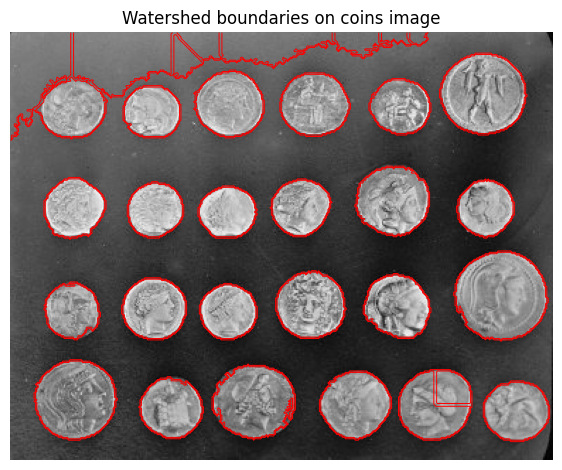

In [72]:
boundaries_coins = segmentation.find_boundaries(labels_coins_ws, mode="outer")

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(image, cmap="gray")
ax.contour(boundaries_coins, colors="red", linewidths=0.7)
ax.set_title("Watershed boundaries on coins image")
ax.axis("off")

plt.savefig(
    "../figures/figures_watershed_segmentation/coins_watershed_boundaries.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

In [73]:
"""
Discusión
El método de watershed es especialmente útil cuando la segmentación binaria produce objetos fusionados.
Su principal ventaja radica en que convierte una región conectada en múltiples candidatos a objetos utilizando información geométrica del mapa de distancias.
Sin embargo, este método es sensible a la selección de marcadores:
- Los marcadores deficientes pueden causar sobresegmentación.
- Los marcadores débiles pueden dejar objetos fusionados.
- El ruido puede crear falsos máximos.
Perspectiva de la imagen real
El método de watershed es útil cuando los objetos son físicamente distintos, pero aparecen conectados en la máscara segmentada.
Ejemplos:
- Granos que se tocan en materiales granulares.
- Poros fusionados en tomografía.
- Partículas agrupadas.
- Células o núcleos en microscopía.
El método de cuencas hidrográficas no suele ser el primer paso de la segmentación, sino un paso de refinamiento que se aplica después del threshold y la limpieza de la máscara.
"""


'\nDiscusión\nEl método de watershed es especialmente útil cuando la segmentación binaria produce objetos fusionados.\nSu principal ventaja radica en que convierte una región conectada en múltiples candidatos a objetos utilizando información geométrica del mapa de distancias.\nSin embargo, este método es sensible a la selección de marcadores:\n- Los marcadores deficientes pueden causar sobresegmentación.\n- Los marcadores débiles pueden dejar objetos fusionados.\n- El ruido puede crear falsos máximos.\nPerspectiva de la imagen real\nEl método de watershed es útil cuando los objetos son físicamente distintos, pero aparecen conectados en la máscara segmentada.\nEjemplos:\n- Granos que se tocan en materiales granulares.\n- Poros fusionados en tomografía.\n- Partículas agrupadas.\n- Células o núcleos en microscopía.\nEl método de cuencas hidrográficas no suele ser el primer paso de la segmentación, sino un paso de refinamiento que se aplica después del threshold y la limpieza de la máscara